# MURA x-ray classification using Inception model

## Data Preprocessing

In [1]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#import libararies
import os
import glob
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

In [7]:
# Set the path
onedrive_path = '/content/drive/MyDrive/Extra_work/MURA/MURA-v1.1/'
csv_files = glob.glob(onedrive_path + 'final*.csv')

dfs = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    dfs.append(df)

mura_df = pd.concat(dfs, ignore_index=True)

mura_df.to_csv(onedrive_path + 'final_mura_dataset.csv', index=False)

print("\n\tTotal Elbow Images",len(mura_df))
mura_df.head(3)


	Total Elbow Images 1126814


,path,class,label
0,MURA-v1.1/train/XR_FOREARM/patient09083/study1...,XR_FOREARM_POSITIVE,POSITIVE
1,MURA-v1.1/train/XR_FOREARM/patient09083/study1...,XR_FOREARM_POSITIVE,POSITIVE
2,MURA-v1.1/train/XR_FOREARM/patient05601/study1...,XR_FOREARM_POSITIVE,POSITIVE


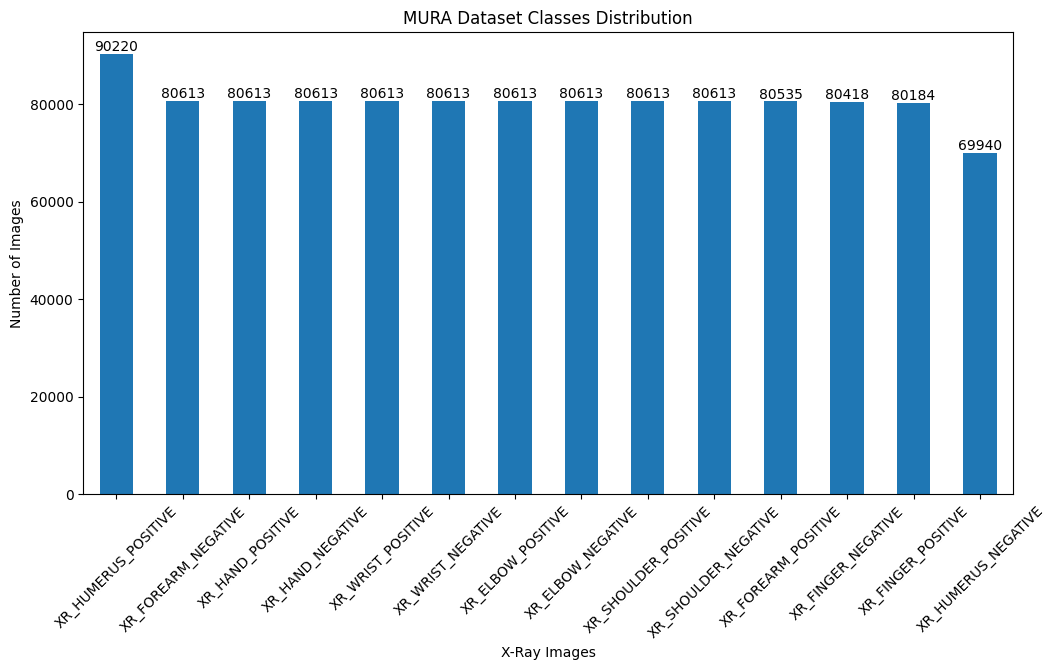

In [8]:
# Count the number of images in each class
mura_df_label_counts = mura_df['class'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = mura_df_label_counts.plot(kind='bar')
plt.title('MURA Dataset Classes Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(mura_df_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

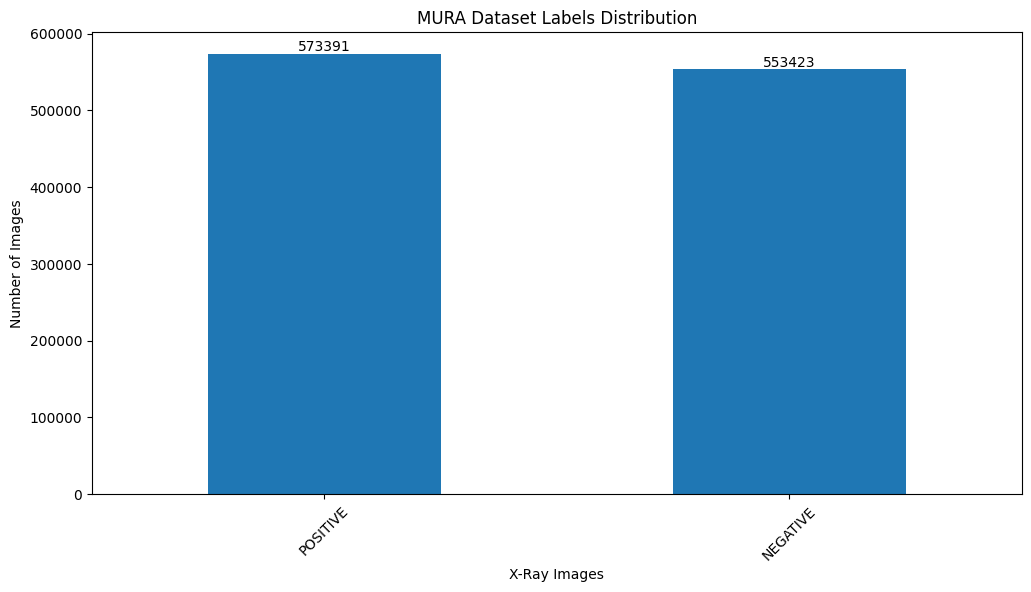

In [9]:
# Count the number of images in each class
mura_df_label_counts = mura_df['label'].value_counts()

# Create a bar chart to visualize the class distribution
plt.figure(figsize=(12, 6))
ax = mura_df_label_counts.plot(kind='bar')
plt.title('MURA Dataset Labels Distribution')
plt.xlabel('X-Ray Images')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Add exact counts as text labels on top of each bar
for i, v in enumerate(mura_df_label_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.show()

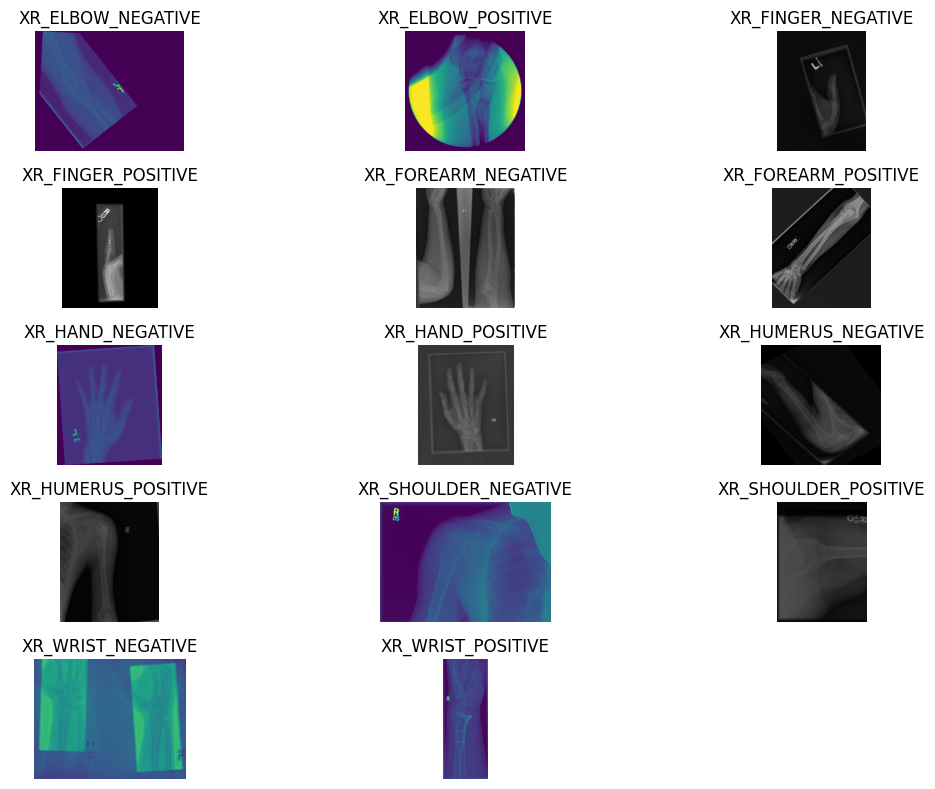

In [10]:
#Display Images of Each class
class_groups = mura_df.groupby('class')['path'].apply(list)

# Create a subplot grid based on the number of classes
num_classes = len(class_groups)
cols = 3
rows = (num_classes + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 8))

for i, (class_name, paths) in enumerate(class_groups.items()):
    random_path = "/content/drive/MyDrive/Extra_work/MURA/" + paths[0]

    image = Image.open(os.path.join(random_path))

    row = i // cols
    col = i % cols

    ax = axes[row, col]
    ax.imshow(image)
    ax.set_title(class_name)
    ax.axis('off')

if num_classes % cols != 0:
    for i in range(num_classes, rows * cols):
        fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

In [ ]:
image_dir = "/content/drive/MyDrive/Extra_work/MURA"

# Split the data into training, validation, and test sets
train_df, test_df = train_test_split(mura_df, test_size=0.15, random_state=42)
val_df, test_df = train_test_split(mura_df, test_size=0.20, random_state=42)

In [ ]:
# Define image data generators for training, validation, and testing

batch_size = 1
image_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


Found 663086 validated image filenames belonging to 14 classes.


In [ ]:
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 624081 validated image filenames belonging to 14 classes.


In [ ]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=image_dir,
    x_col='path',
    y_col='class',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 156021 validated image filenames belonging to 14 classes.


# Train Model

In [ ]:
# Create InceptionV3 base model
base_model = InceptionV3(weights='imagenet', include_top=False)

# Add custom layers for multi-class classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)

num_classes = 14
predictions = Dense(num_classes, activation='softmax')(x)

# Combine base model and custom layers
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

87910968/87910968 [==============================] - 0s 0us/step


In [ ]:
# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)

# Define model checkpoint callback to save the best model
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/Extra_work/MURA/mura_best_model_1.h5',
                                   monitor='val_accuracy',
                                   mode='max',
                                   save_best_only=True)

In [ ]:
# Define the number of training epochs
epochs = 50

# Train the model
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=epochs,
                    callbacks=[early_stopping, model_checkpoint])


Epoch 1/50
 75425/663086 [==>...........................] - ETA: 24:06:23 - loss: 1.5596 - accuracy: 0.3622

# Create small dataset

In [19]:
# Initialize an empty DataFrame for the small version
small_data = pd.DataFrame(columns=['path', 'class', 'label'])

# Define the number of samples you want from each class (550 in this case)
samples_per_class = 550

# Iterate through each class and select the specified number of samples
for class_name in mura_df['class'].unique():
    class_subset = mura_df[mura_df['class'] == class_name].sample(samples_per_class)
    small_data = small_data.append(class_subset, ignore_index=True)

# Shuffle the small dataset to randomize the order
small_data = small_data.sample(frac=1).reset_index(drop=True)

# Save the small dataset to a new CSV file
small_data.to_csv('/content/drive/MyDrive/Extra_work/Sub_dataset/small_data.csv', index=False)

<ipython-input-19-173096b89c93>:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  small_data = small_data.append(class_subset, ignore_index=True)


In [17]:
print("\n\tTotal Training Images",len(train_df))
train_df.head(3)


	Total Training Images 14


,path,class,label
0,[MURA-v1.1/train/XR_ELBOW/augumented_data_xr_e...,XR_ELBOW_NEGATIVE,NaN
1,[MURA-v1.1/train/XR_ELBOW/augumented_data_xr_e...,XR_ELBOW_POSITIVE,NaN
2,[MURA-v1.1/train/XR_FINGER/augumented_data_xr_...,XR_FINGER_NEGATIVE,NaN


In [14]:
print("\n\tTotal Validation Images",len(valid_df))
valid_df.head(3)


	Total Training Images 14


,path,class,label
0,[MURA-v1.1/train/XR_ELBOW/patient06278/study1_...,XR_ELBOW_NEGATIVE,NaN
1,[MURA-v1.1/train/XR_ELBOW/augumented_data_xr_e...,XR_ELBOW_POSITIVE,NaN
2,[MURA-v1.1/train/XR_FINGER/patient03897/study1...,XR_FINGER_NEGATIVE,NaN


In [15]:
print("\n\tTotal Validation Images",len(test_df))
test_df.head(3)


	Total Validation Images 14


,path,class,label
0,[MURA-v1.1/train/XR_ELBOW/patient04938/study2_...,XR_ELBOW_NEGATIVE,NaN
1,[MURA-v1.1/train/XR_ELBOW/patient04904/study1_...,XR_ELBOW_POSITIVE,NaN
2,[MURA-v1.1/train/XR_FINGER/patient03230/study2...,XR_FINGER_NEGATIVE,NaN


### Testing

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the saved model from Google Drive
model_path = '/content/drive/MyDrive/Extra_work/elbow_xray_classification/elbow_best_model.h5'
model = load_model(model_path)

# Make predictions on the test data
predictions = model.predict(test_generator)

# Convert predictions to binary (0 or 1) based on a threshold (e.g., 0.5)
threshold = 0.5
binary_predictions = (predictions > threshold).astype(int)

# Display the first few predictions
print("Sample Predictions:")
print(binary_predictions[:5])

78/78 [==============================] - 491s 6s/step
Sample Predictions:
[[0]
 [0]
 [0]
 [1]
 [1]]


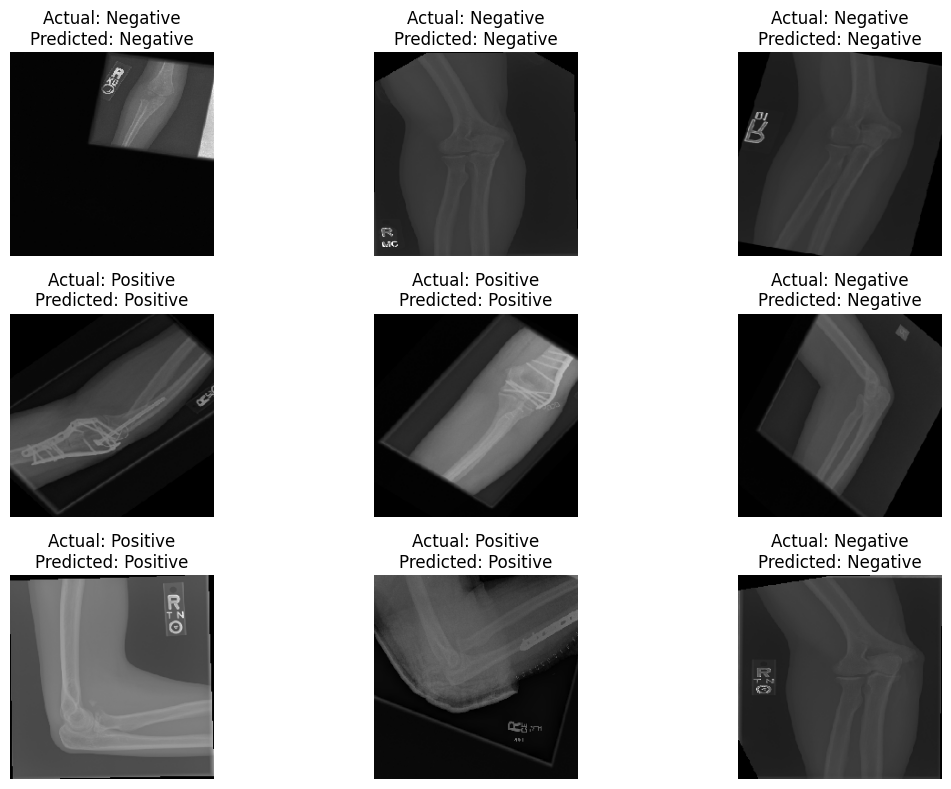

In [ ]:
# Get some test images for display
test_images, test_labels = next(test_generator)

# Create a 3x3 grid of subplots to display images and their labels
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i])
    true_label = "Actual: Negative" if test_labels[i] == 0 else "Actual: Positive"
    pred_label = "Predicted: Negative" if binary_predictions[i] == 0 else "Predicted: Positive"
    plt.title(f"{true_label}\n{pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

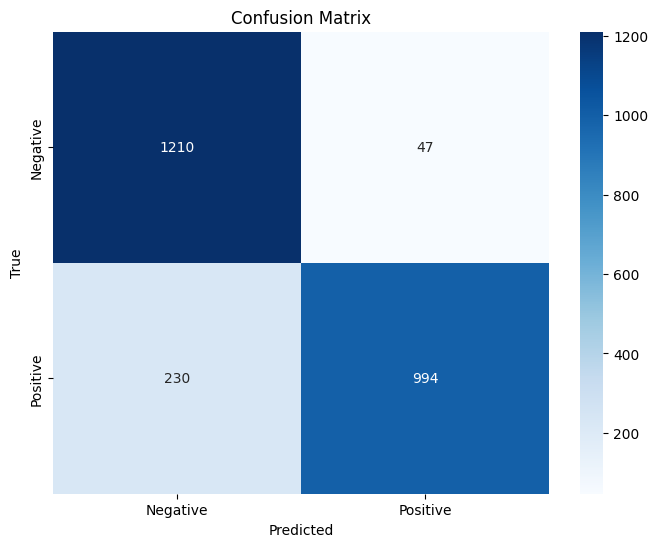

In [ ]:
# Get the true labels from the test generator
true_labels = test_generator.classes

# Calculate the confusion matrix
confusion = confusion_matrix(true_labels, binary_predictions)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Calculate the F1 score
f1 = f1_score(true_labels, binary_predictions)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8777


# Tranfer learn

In [ ]:
from tensorflow.keras.models import load_model

# Load the previously saved model
saved_model_path = '/content/drive/MyDrive/shuoder_xray_model/best_model.h5'
model = load_model(saved_model_path)

In [ ]:
# Compile the model (you can adjust the learning rate if needed)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Define model checkpoint callback to save the best model
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/TL_shoulder_xray_model/TL_best_model.h5',
                                   monitor='val_loss',
                                   save_best_only=True)

In [ ]:
# Define the number of additional training epochs
additional_epochs = 30

# Train the model further
history = model.fit(train_generator,
                    validation_data=val_generator,
                    epochs=additional_epochs,
                    callbacks=[early_stopping, model_checkpoint])

Epoch 1/30
330/330 [==============================] - ETA: 0s - loss: 0.1208 - accuracy: 0.9548 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


330/330 [==============================] - 5436s 16s/step - loss: 0.1208 - accuracy: 0.9548 - val_loss: 0.0550 - val_accuracy: 0.9807
Epoch 2/30
330/330 [==============================] - 303s 919ms/step - loss: 0.1036 - accuracy: 0.9602 - val_loss: 0.1146 - val_accuracy: 0.9642
Epoch 3/30
330/330 [==============================] - 280s 847ms/step - loss: 0.1129 - accuracy: 0.9550 - val_loss: 0.1411 - val_accuracy: 0.9518
Epoch 4/30
330/330 [==============================] - 271s 823ms/step - loss: 0.1061 - accuracy: 0.9601 - val_loss: 0.0687 - val_accuracy: 0.9743
Epoch 5/30
330/330 [==============================] - 281s 850ms/step - loss: 0.1073 - accuracy: 0.9594 - val_loss: 0.0749 - val_accuracy: 0.9705
Epoch 6/30
330/330 [==============================] - 276s 838ms/step - loss: 0.0995 - accuracy: 0.9618 - val_loss: 0.1194 - val_accuracy: 0.9561


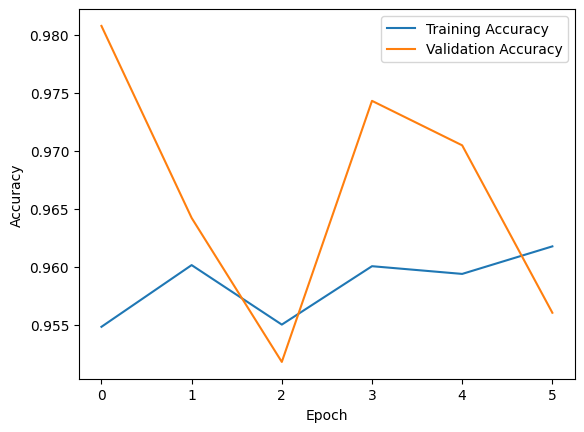

In [ ]:
# Visualize training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

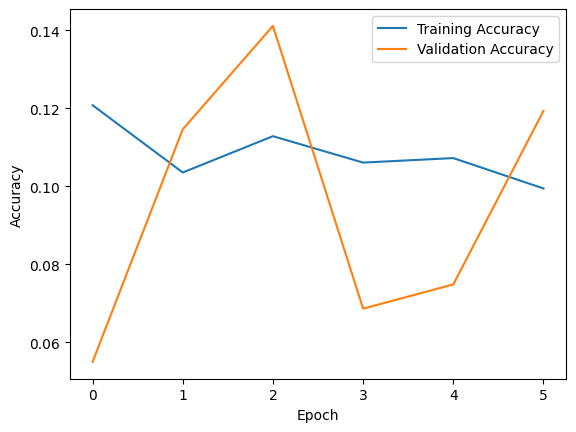

In [ ]:
# Visualize training accuracy
plt.plot(history.history['loss'], label='Training Accuracy')
plt.plot(history.history['val_loss'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Testing

In [ ]:
# Load the saved model from Google Drive
model_path = '/content/drive/MyDrive/TL_shoulder_xray_model/TL_best_model.h5'
model = load_model(model_path)

# Make predictions on the test data
predictions = model.predict(test_generator)

# Convert predictions to binary (0 or 1) based on a threshold (e.g., 0.5)
threshold = 0.5
binary_predictions = (predictions > threshold).astype(int)

# Display the first few predictions
print("Sample Predictions:")
print(binary_predictions[:5])

78/78 [==============================] - 906s 12s/step
Sample Predictions:
[[0]
 [0]
 [0]
 [1]
 [1]]


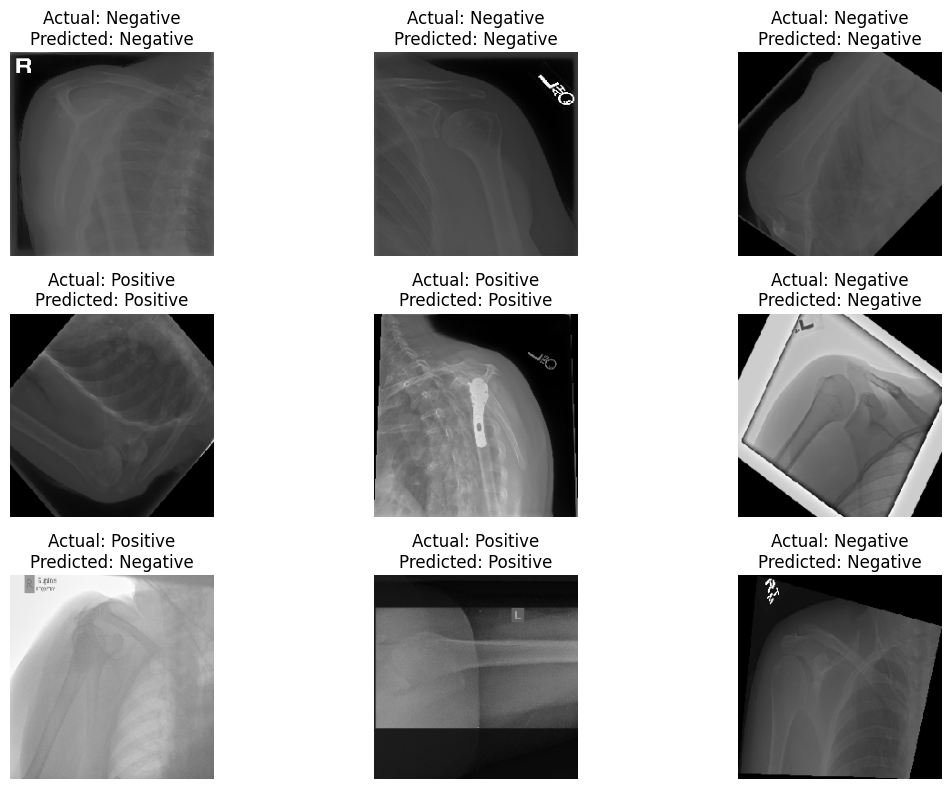

In [ ]:
# Get some test images for display
test_images, test_labels = next(test_generator)

# Create a 3x3 grid of subplots to display images and their labels
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_images[i])
    true_label = "Actual: Negative" if test_labels[i] == 0 else "Actual: Positive"
    pred_label = "Predicted: Negative" if binary_predictions[i] == 0 else "Predicted: Positive"
    plt.title(f"{true_label}\n{pred_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

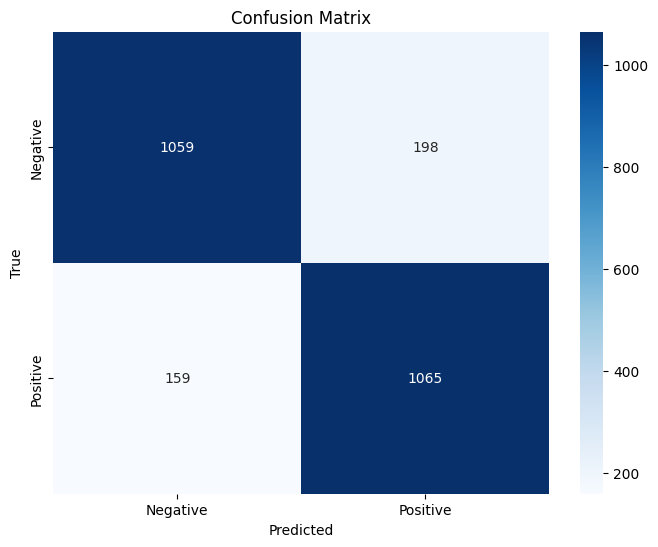

In [ ]:
# Get the true labels from the test generator
true_labels = test_generator.classes

# Calculate the confusion matrix
confusion = confusion_matrix(true_labels, binary_predictions)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Calculate the F1 score
f1 = f1_score(true_labels, binary_predictions)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8565


In [ ]:
history.history

{'loss': [0.12081655859947205,
  0.10357082635164261,
  0.11287469416856766,
  0.10610241442918777,
  0.10726017504930496,
  0.09947048127651215],
 'accuracy': [0.9548429846763611,
  0.9601556062698364,
  0.9550327062606812,
  0.960060715675354,
  0.9593966603279114,
  0.9617683291435242],
 'val_loss': [0.055003952234983444,
  0.11463043093681335,
  0.14114198088645935,
  0.06866177171468735,
  0.0748765841126442,
  0.11936438828706741],
 'val_accuracy': [0.9807479381561279,
  0.9642173051834106,
  0.9518193602561951,
  0.9742969274520874,
  0.970466673374176,
  0.956052839756012]}